In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/superstore_clean.csv')
print("Shape:", df.shape)
df.head()

Shape: (9994, 26)


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_name,sales,quantity,discount,profit,order_year,order_month,order_day,shipping_date,shipping_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,Tuesday,3,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,Tuesday,3,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,Sunday,4,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,Sunday,7,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,Sunday,7,7


In [2]:
print("Total Sales:   $", round(df['sales'].sum(), 2))
print("Total Profit:  $", round(df['profit'].sum(), 2))
print("Total Orders:     ", df['order_id'].nunique())
print("Profit Margin:  ", round((df['profit'].sum() / df['sales'].sum()) * 100, 2), "%")

Total Sales:   $ 2297200.86
Total Profit:  $ 286397.02
Total Orders:      5009
Profit Margin:   12.47 %


In [3]:
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)
print(category_sales)


category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64


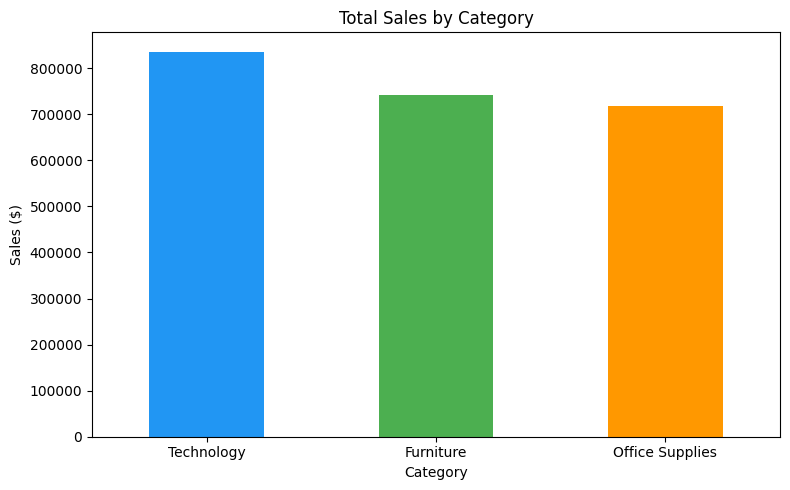

Chart saved!


In [4]:
plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/sales_by_category.png')
plt.show()
print("Chart saved!")

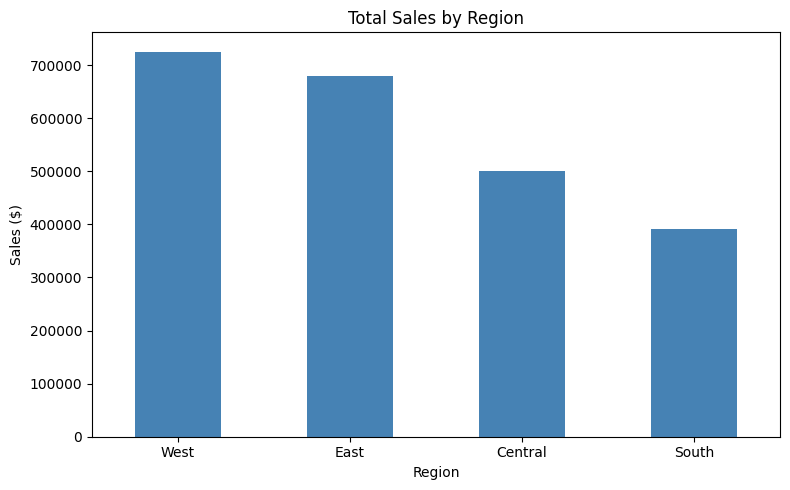

In [5]:
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/sales_by_region.png')
plt.show()

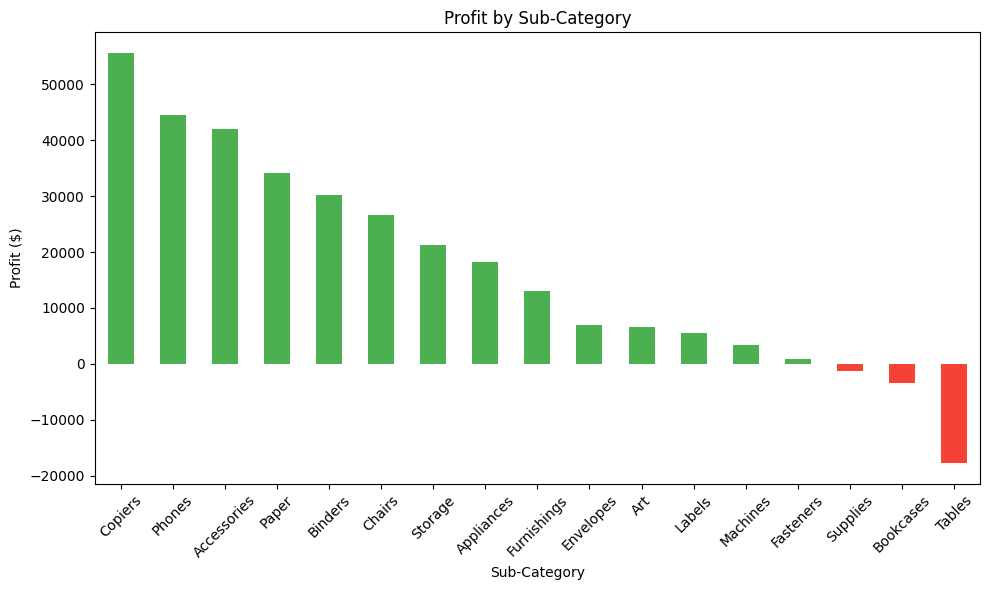

In [9]:
sub_profit = df.groupby('sub-category')['profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#4CAF50' if x > 0 else '#F44336' for x in sub_profit]
sub_profit.plot(kind='bar', color=colors)
plt.title('Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Profit ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/profit_by_subcategory.png')
plt.show()

In [8]:
print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'order_year', 'order_month', 'order_day', 'shipping_date', 'shipping_days']


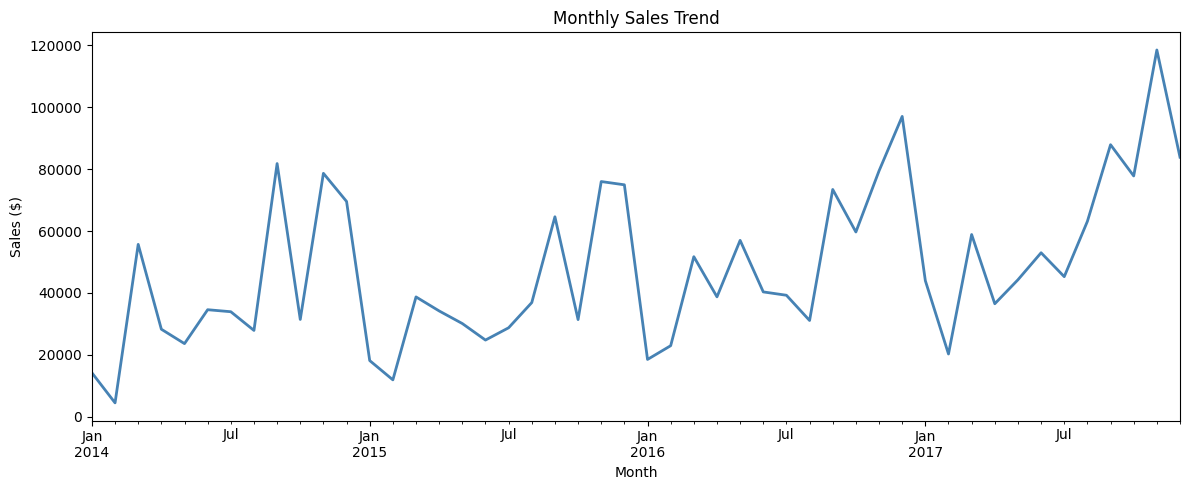

In [10]:
df['order_date'] = pd.to_datetime(df['order_date'])
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('../outputs/monthly_sales_trend.png')
plt.show()

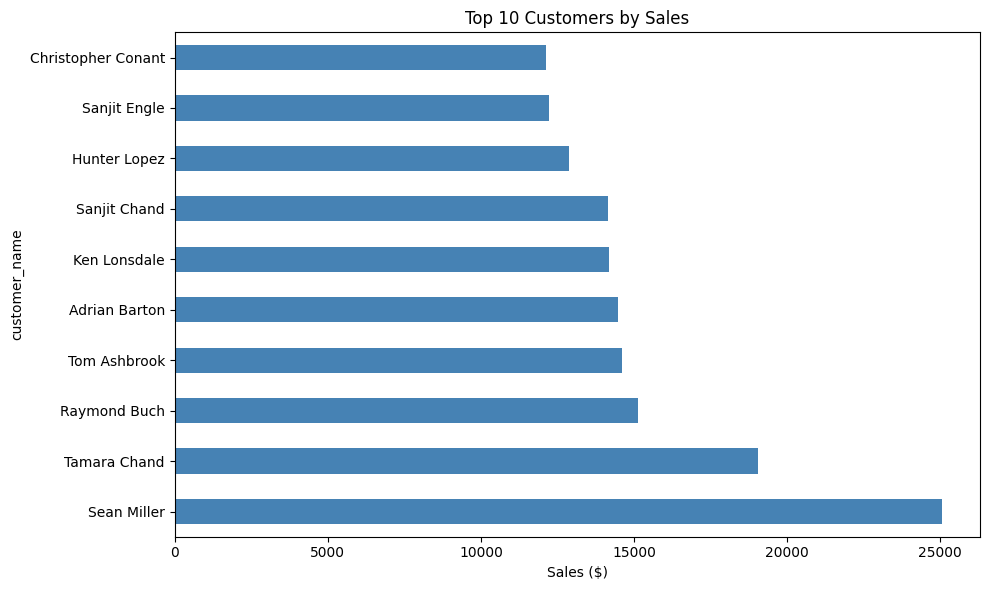

In [11]:
top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_customers.plot(kind='barh', color='steelblue')
plt.title('Top 10 Customers by Sales')
plt.xlabel('Sales ($)')
plt.tight_layout()
plt.savefig('../outputs/top_customers.png')
plt.show()